In [3]:
# How many images?
print("Training images :", len(train_data))   # → 50000
print("Test images     :", len(test_data))    # → 10000

# How many categories?
print("Total classes   :", len(train_data.classes))  # → 100

# What are the first 10 categories?
print("\nFirst 10 classes:")
for i, name in enumerate(train_data.classes[:10]):
    print(f"  {i:02d}. {name}")

Training images : 50000
Test images     : 10000
Total classes   : 100

First 10 classes:
  00. apple
  01. aquarium_fish
  02. baby
  03. bear
  04. beaver
  05. bed
  06. bee
  07. beetle
  08. bicycle
  09. bottle


Image type   : <class 'PIL.Image.Image'>
Image size   : (32, 32)
Label number : 19
Label name   : cattle


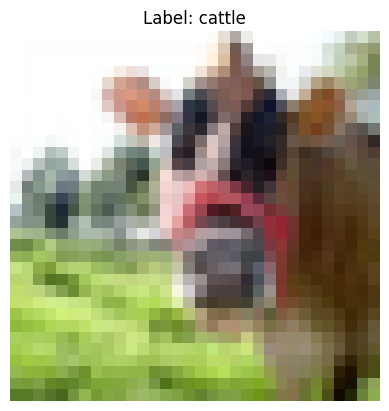

In [4]:
import matplotlib.pyplot as plt

# Get the very first image and its label
image, label = train_data[0]

print(f"Image type   : {type(image)}")
print(f"Image size   : {image.size}")       # → (32, 32)
print(f"Label number : {label}")
print(f"Label name   : {train_data.classes[label]}")

# Show the image
plt.imshow(image)
plt.title(f"Label: {train_data.classes[label]}")
plt.axis('off')
plt.show()

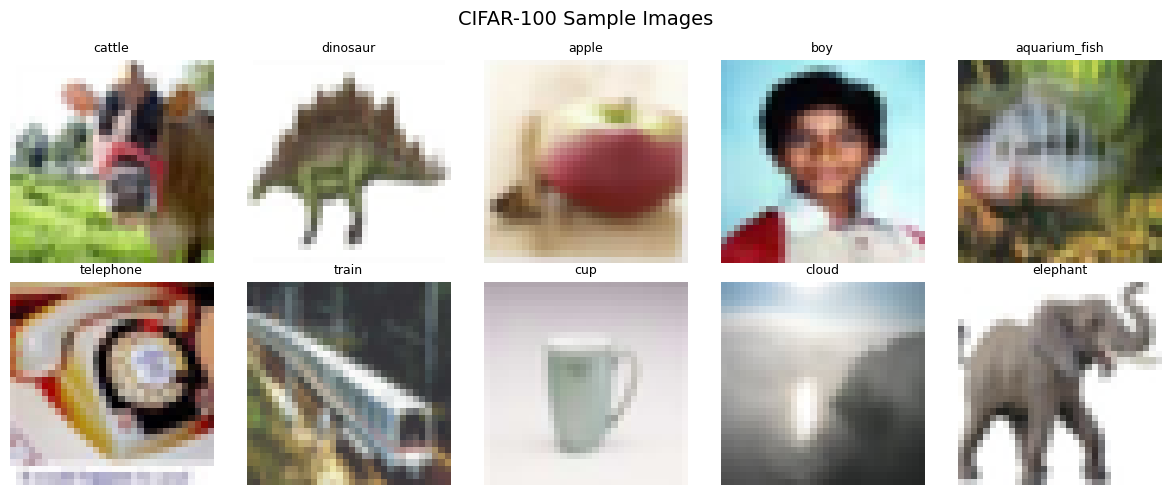

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    image, label = train_data[i]
    ax.imshow(image)
    ax.set_title(train_data.classes[label], fontsize=9)
    ax.axis('off')

plt.suptitle("CIFAR-100 Sample Images", fontsize=14)
plt.tight_layout()
plt.show()

In [6]:
import os

# Check the downloaded files
for root, dirs, files in os.walk('./data'):
    for file in files:
        filepath = os.path.join(root, file)
        size_mb = os.path.getsize(filepath) / (1024*1024)
        print(f"{filepath}  ({size_mb:.1f} MB)")
        

./data/cifar-100-python.tar.gz  (161.2 MB)
./data/cifar-100-python/test  (29.6 MB)
./data/cifar-100-python/meta  (0.0 MB)
./data/cifar-100-python/train  (148.1 MB)
./data/cifar-100-python/file.txt~  (0.0 MB)


In [7]:
!pip install timm --quiet

In [9]:
import timm
import torch

# Load the model (downloads ~20MB of pre-trained weights)
model = timm.create_model(
    'efficientnet_b0',   # model name
    pretrained=True,     # use weights pre-trained on ImageNet
    num_classes=100      # we need 100 outputs (one per CIFAR class)
)

print("✅ Model loaded!")
print(f"Model type: {type(model)}")

✅ Model loaded!
Model type: <class 'timm.models.efficientnet.EfficientNet'>


In [10]:
# Count total parameters
total_params = sum(p.numel() for p in model.parameters())

# Count trainable parameters  
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable:,}")
print(f"Size in MB          : {total_params * 4 / 1024 / 1024:.1f} MB")

Total parameters    : 4,135,648
Trainable parameters: 4,135,648
Size in MB          : 15.8 MB


In [11]:
# See the layers — like reading a class diagram
# Warning: it's long! Just scroll to see the last layer

# Just show the LAST layer (the classification head)
print("Last layer (classifier):")
print(model.classifier)
print()
print(f"Input features : {model.classifier.in_features}")
print(f"Output classes : {model.classifier.out_features}")

Last layer (classifier):
Linear(in_features=1280, out_features=100, bias=True)

Input features : 1280
Output classes : 100


In [13]:
import torchvision
import torch

# Load one test image
test_data = torchvision.datasets.CIFAR100('./data', train=False, download=True)
image, true_label = test_data[0]

# Convert image to tensor (model needs tensor, not PIL image)
from torchvision import transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])
image_tensor = transform(image).unsqueeze(0)  # Add batch dimension

# Get prediction (before any training)
model.eval()
with torch.no_grad():
    output = model(image_tensor)       # Forward pass
    probabilities = torch.softmax(output, dim=1)
    predicted_label = output.argmax(1).item()
    confidence = probabilities[0][predicted_label].item() * 100

# Show result
print(f"True label      : {test_data.classes[true_label]}")
print(f"Predicted label : {test_data.classes[predicted_label]}")
print(f"Confidence      : {confidence:.2f}%")
print()
if predicted_label == true_label:
    print("✅ Correct! (Lucky guess)")
else:
    print("❌ Wrong (Expected! Model not trained on CIFAR-100 yet)")

True label      : mountain
Predicted label : clock
Confidence      : 8.82%

❌ Wrong (Expected! Model not trained on CIFAR-100 yet)


Original image type : <class 'PIL.Image.Image'>
Original image size : (32, 32)


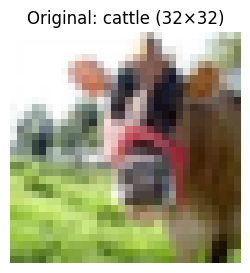

In [14]:
from torchvision import transforms
from torchvision import datasets
import matplotlib.pyplot as plt
import numpy as np

# Load raw data first (no transforms yet)
raw_data = datasets.CIFAR100('./data', train=True, download=True)

# Get one sample image
sample_image, sample_label = raw_data[0]

print(f"Original image type : {type(sample_image)}")
print(f"Original image size : {sample_image.size}")  # (32, 32)

# Show original
plt.figure(figsize=(3, 3))
plt.imshow(sample_image)
plt.title(f"Original: {raw_data.classes[sample_label]} (32×32)")
plt.axis('off')
plt.show()

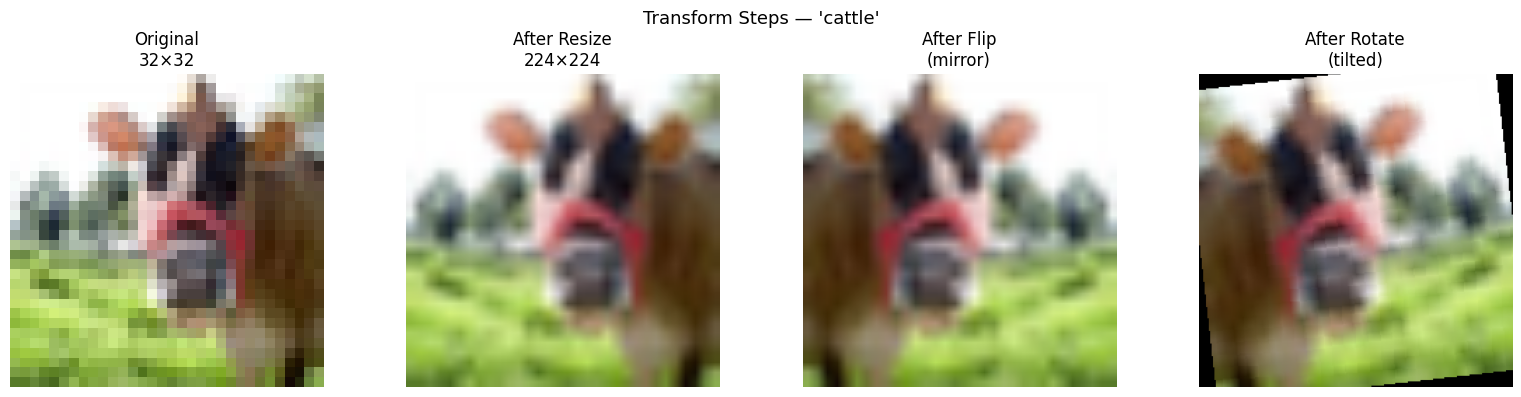

In [15]:
# STEP 1: Just Resize
transform_resize = transforms.Compose([
    transforms.Resize((224, 224))
])

# STEP 2: Resize + Flip
transform_flip = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=1.0)  # p=1.0 means always flip
])

# STEP 3: Resize + Flip + Rotation
transform_rotate = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=1.0),
    transforms.RandomRotation(15)  # rotate up to 15 degrees
])

# Show all versions side by side
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(sample_image)
axes[0].set_title("Original\n32×32")

axes[1].imshow(transform_resize(sample_image))
axes[1].set_title("After Resize\n224×224")

axes[2].imshow(transform_flip(sample_image))
axes[2].set_title("After Flip\n(mirror)")

axes[3].imshow(transform_rotate(sample_image))
axes[3].set_title("After Rotate\n(tilted)")

for ax in axes:
    ax.axis('off')

plt.suptitle(f"Transform Steps — '{raw_data.classes[sample_label]}'", fontsize=13)
plt.tight_layout()
plt.show()

In [16]:
import torch
from torchvision import transforms

# Convert image to tensor (numbers)
to_tensor = transforms.ToTensor()
image_tensor = to_tensor(transforms.Resize((224, 224))(sample_image))

print("BEFORE normalization:")
print(f"  Shape  : {image_tensor.shape}")   # [3, 224, 224]
print(f"  Min    : {image_tensor.min():.3f}")
print(f"  Max    : {image_tensor.max():.3f}")
print(f"  Values : 0.0 to 1.0")

# Now normalize
# These numbers are pre-calculated average brightness of CIFAR-100
MEAN = [0.5071, 0.4867, 0.4408]
STD  = [0.2675, 0.2565, 0.2761]

normalize = transforms.Normalize(MEAN, STD)
normalized = normalize(image_tensor)

print("\nAFTER normalization:")
print(f"  Min    : {normalized.min():.3f}")
print(f"  Max    : {normalized.max():.3f}")
print(f"  Values : now centered around 0")

BEFORE normalization:
  Shape  : torch.Size([3, 224, 224])
  Min    : 0.004
  Max    : 1.000
  Values : 0.0 to 1.0

AFTER normalization:
  Min    : -1.790
  Max    : 2.025
  Values : now centered around 0


In [17]:
from torchvision import transforms

# CIFAR-100 statistics
MEAN     = [0.5071, 0.4867, 0.4408]
STD      = [0.2675, 0.2565, 0.2761]
IMG_SIZE = 224

# ── TRAINING transforms ──────────────────────────────────────────
# Has augmentation (flip, rotate, color jitter)
# Each epoch sees slightly different versions → model learns better
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),          # 32×32 → 224×224
    transforms.RandomHorizontalFlip(p=0.5),           # 50% chance flip
    transforms.RandomRotation(15),                     # tilt up to 15°
    transforms.ColorJitter(                            # slight color change
        brightness=0.3,
        contrast=0.3,
        saturation=0.3
    ),
    transforms.ToTensor(),                             # PIL → tensor
    transforms.Normalize(MEAN, STD)                   # normalize
])

# ── TEST transforms ──────────────────────────────────────────────
# NO augmentation — clean evaluation only
# We never augment test data!
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

print("✅ Train transform steps:")
for i, t in enumerate(train_transform.transforms):
    print(f"   {i+1}. {t.__class__.__name__}")

print("\n✅ Test transform steps:")
for i, t in enumerate(test_transform.transforms):
    print(f"   {i+1}. {t.__class__.__name__}")

✅ Train transform steps:
   1. Resize
   2. RandomHorizontalFlip
   3. RandomRotation
   4. ColorJitter
   5. ToTensor
   6. Normalize

✅ Test transform steps:
   1. Resize
   2. ToTensor
   3. Normalize


In [18]:
from torchvision import datasets

# Attach transforms to datasets
train_dataset = datasets.CIFAR100(
    root='./data',
    train=True,                    # training set
    transform=train_transform,     # apply augmentation
    download=True
)

test_dataset = datasets.CIFAR100(
    root='./data',
    train=False,                   # test set
    transform=test_transform,      # no augmentation
    download=True
)

# Verify one item
image_tensor, label = train_dataset[0]

print(f"Image shape : {image_tensor.shape}")  # [3, 224, 224]
print(f"Image type  : {image_tensor.dtype}")  # torch.float32
print(f"Label       : {label} = '{train_dataset.classes[label]}'")
print(f"Train size  : {len(train_dataset)}")
print(f"Test size   : {len(test_dataset)}")


Image shape : torch.Size([3, 224, 224])
Image type  : torch.float32
Label       : 19 = 'cattle'
Train size  : 50000
Test size   : 10000


In [20]:
from torch.utils.data import DataLoader

# DataLoader = delivers images in BATCHES to the model
train_loader = DataLoader(
    train_dataset,
    batch_size=128,    # send 128 images at once
    shuffle=True,      # shuffle order every epoch
    num_workers=2,     # parallel loading (2 background threads)
    pin_memory=False    # faster GPU transfer
)

test_loader = DataLoader(
    test_dataset,
    batch_size=256,    # larger batch ok for testing (no gradients)
    shuffle=False,     # keep original order for evaluation
    num_workers=2,
    pin_memory=False
)

print(f"Train batches : {len(train_loader)}")  # 50000 ÷ 128 = 391
print(f"Test batches  : {len(test_loader)}")   # 10000 ÷ 256 = 40

# Peek at one batch
images_batch, labels_batch = next(iter(train_loader))
print(f"\nOne batch shape : {images_batch.shape}")
# → torch.Size([128, 3, 224, 224])
# →             ↑    ↑  ↑    ↑
# →          128imgs RGB 224  224

Train batches : 391
Test batches  : 40

One batch shape : torch.Size([128, 3, 224, 224])


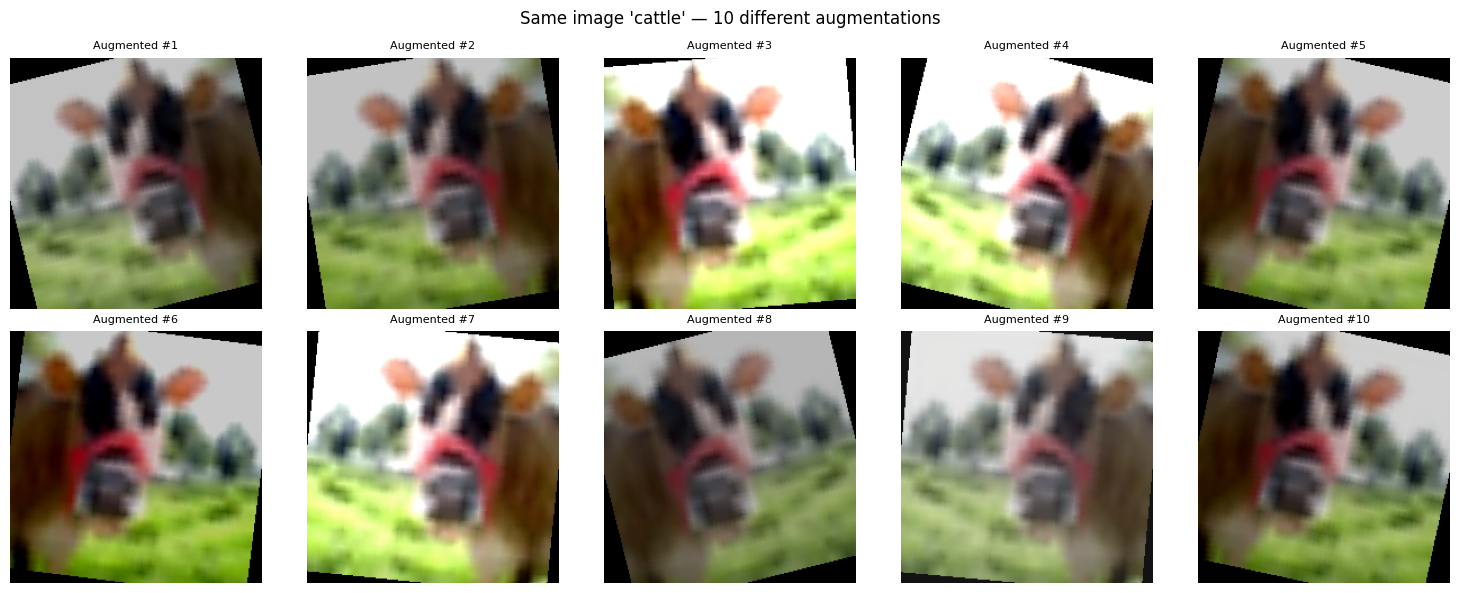

In [21]:
import matplotlib.pyplot as plt

# Show same image 6 times — each time different augmentation
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flat):
    # Same image index but transform is random each time
    img_tensor, lbl = train_dataset[0]

    # Convert tensor back to displayable image
    # Undo normalization for display
    mean = torch.tensor(MEAN).view(3, 1, 1)
    std  = torch.tensor(STD).view(3, 1, 1)
    img_display = (img_tensor * std + mean).clamp(0, 1)
    img_display = img_display.permute(1, 2, 0).numpy()

    ax.imshow(img_display)
    ax.set_title(f"Augmented #{i+1}", fontsize=8)
    ax.axis('off')

plt.suptitle(
    f"Same image '{train_dataset.classes[lbl]}' — "
    "10 different augmentations",
    fontsize=12
)
plt.tight_layout()
plt.show()

In [39]:
import torch
import timm
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
import time, os

os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'

DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
MEAN   = [0.5071, 0.4867, 0.4408]
STD    = [0.2675, 0.2565, 0.2761]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(224, padding=28),   # ← NEW: helps overfitting
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

train_dataset = datasets.CIFAR100('./data', train=True,
                                   transform=train_transform, download=True)
test_dataset  = datasets.CIFAR100('./data', train=False,
                                   transform=test_transform,  download=True)

train_loader = DataLoader(train_dataset, batch_size=64,
                          shuffle=True,  num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_dataset,  batch_size=128,
                          shuffle=False, num_workers=0, pin_memory=False)

# ── Model ─────────────────────────────────────────────────────────
model = timm.create_model('efficientnet_b0', pretrained=True, num_classes=100)
model = model.to(DEVICE)

EPOCHS    = 30
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# ── Functions ─────────────────────────────────────────────────────
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    progress = tqdm(loader, desc="  Training", leave=False)
    for images, labels in progress:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total   += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        progress.set_postfix({
            'loss': f'{loss.item():.3f}',
            'acc' : f'{100.*correct/total:.1f}%'
        })
    return total_loss / len(loader), 100. * correct / total

def evaluate(model, loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        progress = tqdm(loader, desc="  Evaluating", leave=False)
        for images, labels in progress:
            images, labels = images.to(device), labels.to(device)
            outputs      = model(images)
            _, predicted = outputs.max(1)
            total   += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            progress.set_postfix({'acc': f'{100.*correct/total:.1f}%'})
    return 100. * correct / total

# ── Training Loop with Early Stopping ────────────────────────────
print("🚀 Training with Early Stopping!")
print("=" * 65)

best_accuracy  = 0.0
history        = []
patience       = 5      # ← stop if no improvement for 5 epochs
no_improve     = 0      # ← counter

for epoch in range(1, EPOCHS + 1):
    start_time = time.time()

    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, DEVICE
    )
    test_acc = evaluate(model, test_loader, DEVICE)
    scheduler.step()

    elapsed    = time.time() - start_time
    current_lr = optimizer.param_groups[0]['lr']
    gap        = test_acc - train_acc

    if test_acc > best_accuracy:
        best_accuracy = test_acc
        no_improve    = 0          # reset counter
        torch.save(model.state_dict(), 'best_model.pth')
        best_marker = "⭐ NEW BEST!"
    else:
        no_improve += 1            # increment counter
        best_marker = f"({no_improve}/{patience} patience)"

    history.append({
        'epoch'     : epoch,
        'train_loss': train_loss,
        'train_acc' : train_acc,
        'test_acc'  : test_acc
    })

    print(
        f"Epoch [{epoch:02d}/{EPOCHS}] "
        f"Loss: {train_loss:.3f} | "
        f"Train: {train_acc:.1f}% | "
        f"Test: {test_acc:.1f}% | "
        f"Gap: {gap:+.1f}% | "
        f"Time: {elapsed:.0f}s "
        f"{best_marker}"
    )

    # ── Early Stop Check ──────────────────────────────────────────
    if no_improve >= patience:
        print(f"\n⏹️  Early stopping! No improvement for {patience} epochs.")
        print(f"   Best accuracy was: {best_accuracy:.2f}%")
        break

print("=" * 65)
print(f"🏆 Best Test Accuracy : {best_accuracy:.2f}%")

total_params = sum(p.numel() for p in model.parameters())
score        = best_accuracy / total_params
print(f"   Parameters    : {total_params:,}")
print(f"   Contest Score : {score:.10f}")


🚀 Training with Early Stopping!


Epoch [01/30] Loss: 1.954 | Train: 63.5% | Test: 74.5% | Gap: +11.0% | Time: 371s ⭐ NEW BEST!


Epoch [02/30] Loss: 1.487 | Train: 77.8% | Test: 76.9% | Gap: -0.9% | Time: 377s ⭐ NEW BEST!


Epoch [03/30] Loss: 1.338 | Train: 82.6% | Test: 78.3% | Gap: -4.3% | Time: 367s ⭐ NEW BEST!


Epoch [04/30] Loss: 1.230 | Train: 86.4% | Test: 77.9% | Gap: -8.5% | Time: 348s (1/5 patience)


...

Epoch [26/30] Loss: 0.792 | Train: 99.9% | Test: 85.2% | Gap: -14.8% | Time: 358s ⭐ NEW BEST!


Epoch [27/30] Loss: 0.791 | Train: 99.9% | Test: 85.4% | Gap: -14.5% | Time: 347s ⭐ NEW BEST!


Epoch [28/30] Loss: 0.790 | Train: 100.0% | Test: 85.2% | Gap: -14.8% | Time: 351s (1/5 patience)


Epoch [29/30] Loss: 0.790 | Train: 100.0% | Test: 85.2% | Gap: -14.7% | Time: 410s (2/5 patience)


Epoch [30/30] Loss: 0.789 | Train: 100.0% | Test: 85.4% | Gap: -14.6% | Time: 391s (3/5 patience)
🏆 Best Test Accuracy : 85.44%
   Parameters    : 4,135,648
   Contest Score : 0.0000206594


In [40]:
import torch
import timm
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm

# ── Reload best model from saved file ────────────────────────────
model = timm.create_model('efficientnet_b0', pretrained=False, num_classes=100)
model.load_state_dict(torch.load('best_model.pth', map_location=DEVICE))
model = model.to(DEVICE)
model.eval()

print("✅ Best model loaded from best_model.pth")

# ── Run on full test set ──────────────────────────────────────────
correct, total = 0, 0

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Final Evaluation"):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        outputs      = model(images)
        _, predicted = outputs.max(1)
        total       += labels.size(0)
        correct     += predicted.eq(labels).sum().item()

# ── Calculate contest score ───────────────────────────────────────
final_accuracy = 100. * correct / total
total_params   = sum(p.numel() for p in model.parameters())
contest_score  = final_accuracy / total_params

print()
print("=" * 50)
print("  🏆 CONTEST SCORE CARD")
print("=" * 50)
print(f"  Top-1 Accuracy   : {final_accuracy:.2f}%")
print(f"  Total Parameters : {total_params:,}")
print(f"  Score (Acc/Param) : {contest_score:.10f}")
print("=" * 50)

if final_accuracy > 50:
    print("  ✅ Passes 50% minimum requirement!")
else:
    print("  ❌ Below 50% — need more training")

✅ Best model loaded from best_model.pth


Final Evaluation: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 79/79 [00:18<00:00,  4.18it/s]


  🏆 CONTEST SCORE CARD
  Top-1 Accuracy   : 85.44%
  Total Parameters : 4,135,648
  Score (Acc/Param) : 0.0000206594
  ✅ Passes 50% minimum requirement!


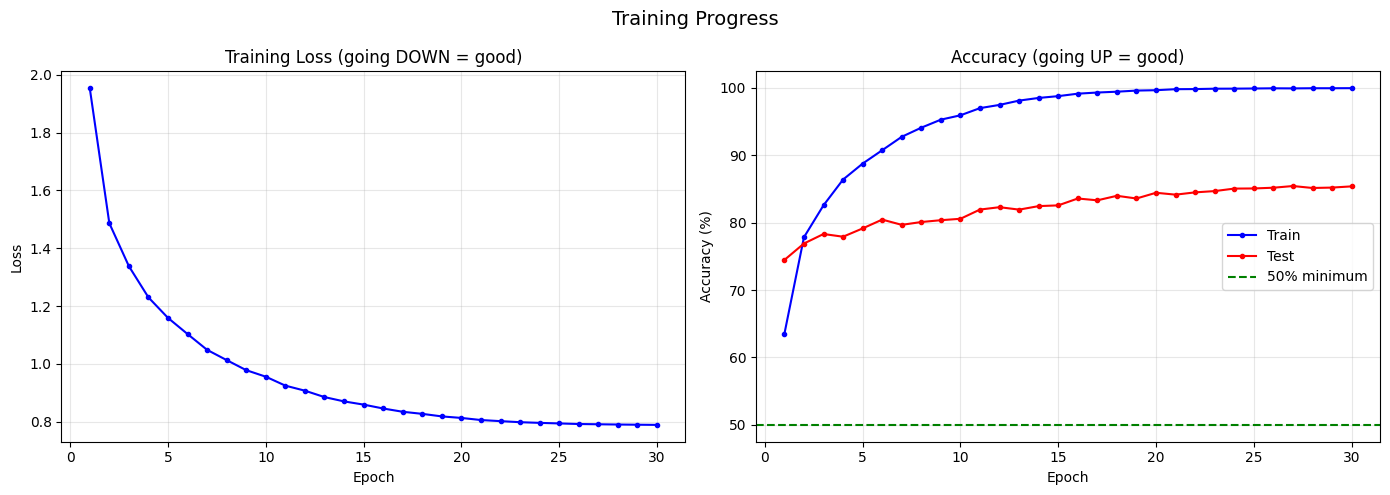

In [41]:
import matplotlib.pyplot as plt

epochs_list  = [h['epoch']      for h in history]
train_losses = [h['train_loss'] for h in history]
train_accs   = [h['train_acc']  for h in history]
test_accs    = [h['test_acc']   for h in history]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
ax1.plot(epochs_list, train_losses, 'b-o', markersize=3)
ax1.set_title('Training Loss (going DOWN = good)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True, alpha=0.3)

# Accuracy curve
ax2.plot(epochs_list, train_accs, 'b-o', markersize=3, label='Train')
ax2.plot(epochs_list, test_accs,  'r-o', markersize=3, label='Test')
ax2.axhline(y=50, color='g', linestyle='--', label='50% minimum')
ax2.set_title('Accuracy (going UP = good)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Training Progress', fontsize=14)
plt.tight_layout()
plt.show()

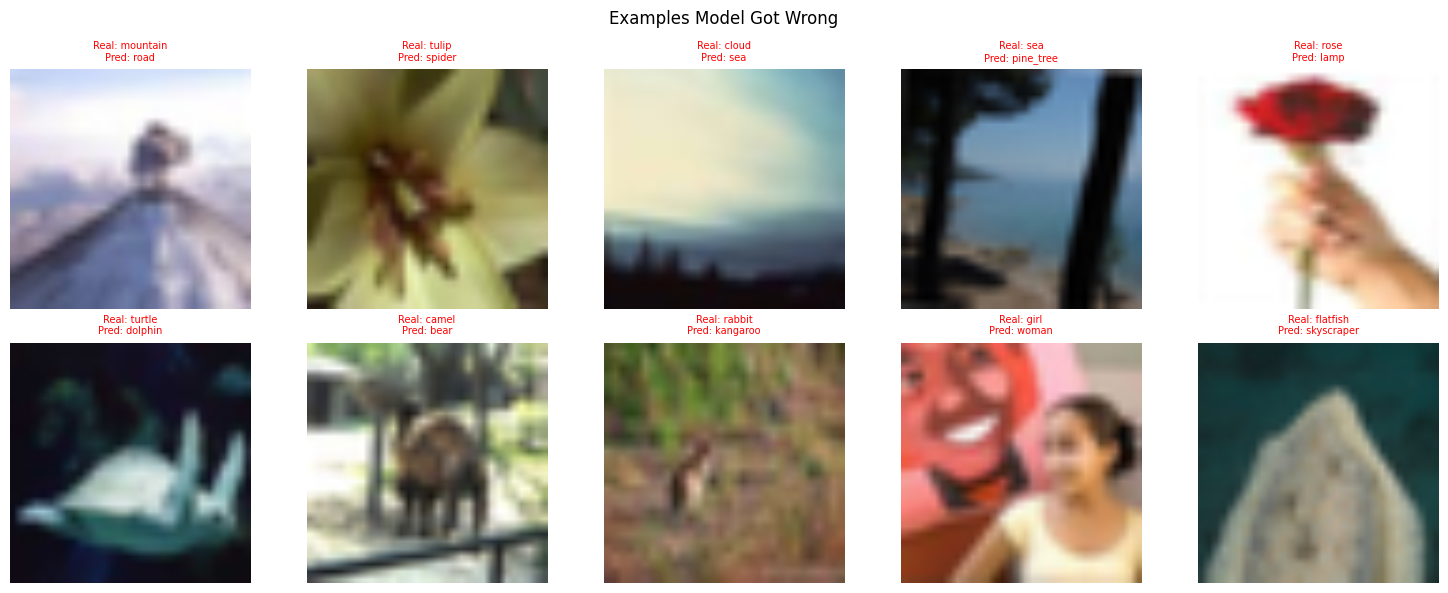

In [42]:
# Show some examples the model got wrong
# Useful to put in your submission report

wrong_images  = []
wrong_preds   = []
wrong_actuals = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        outputs      = model(images)
        _, predicted = outputs.max(1)

        # Find wrong predictions
        wrong_mask = predicted.ne(labels)
        wrong_images.extend(images[wrong_mask].cpu())
        wrong_preds.extend(predicted[wrong_mask].cpu())
        wrong_actuals.extend(labels[wrong_mask].cpu())

        if len(wrong_images) >= 10:
            break

# Display wrong predictions
MEAN_T = torch.tensor([0.5071, 0.4867, 0.4408]).view(3,1,1)
STD_T  = torch.tensor([0.2675, 0.2565, 0.2761]).view(3,1,1)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    img = (wrong_images[i] * STD_T + MEAN_T).clamp(0,1)
    img = img.permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(
        f"Real: {test_dataset.classes[wrong_actuals[i]]}\n"
        f"Pred: {test_dataset.classes[wrong_preds[i]]}",
        fontsize=7, color='red'
    )
    ax.axis('off')

plt.suptitle("Examples Model Got Wrong", fontsize=12)
plt.tight_layout()
plt.show()

In [43]:
# Create train.py file directly from notebook
train_script = '''
import os
import torch
import timm
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
import time

os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

# ── Device ────────────────────────────────────────────────────────
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")
print(f"Device: {DEVICE}")

# ── Config ────────────────────────────────────────────────────────
EPOCHS     = 30
BATCH_SIZE = 64
IMG_SIZE   = 224
MEAN       = [0.5071, 0.4867, 0.4408]
STD        = [0.2675, 0.2565, 0.2761]

# ── Transforms ────────────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

# ── Data ──────────────────────────────────────────────────────────
train_dataset = datasets.CIFAR100("./data", train=True,
                                   transform=train_transform, download=True)
test_dataset  = datasets.CIFAR100("./data", train=False,
                                   transform=test_transform,  download=True)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                           shuffle=True,  num_workers=0, pin_memory=False)
test_loader   = DataLoader(test_dataset,  batch_size=128,
                           shuffle=False, num_workers=0, pin_memory=False)

# ── Model ─────────────────────────────────────────────────────────
model = timm.create_model("efficientnet_b0", pretrained=True, num_classes=100)
model = model.to(DEVICE)

# ── Training Setup ────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(loader, desc="  Training", leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _, pred = model(images).max(1)
        total   += labels.size(0)
        correct += pred.eq(labels).sum().item()
    return total_loss / len(loader), 100. * correct / total

def evaluate(model, loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="  Evaluating", leave=False):
            images, labels = images.to(device), labels.to(device)
            _, pred = model(images).max(1)
            total   += labels.size(0)
            correct += pred.eq(labels).sum().item()
    return 100. * correct / total

# ── Train ─────────────────────────────────────────────────────────
best_accuracy = 0.0
for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, DEVICE)
    test_acc = evaluate(model, test_loader, DEVICE)
    scheduler.step()

    if test_acc > best_accuracy:
        best_accuracy = test_acc
        torch.save(model.state_dict(), "best_model.pth")

    print(f"Epoch [{epoch:02d}/{EPOCHS}] "
          f"Loss: {train_loss:.3f} | "
          f"Train: {train_acc:.1f}% | "
          f"Test: {test_acc:.1f}%")

print(f"Done! Best accuracy: {best_accuracy:.2f}%")
'''

with open('train.py', 'w') as f:
    f.write(train_script)

print("✅ train.py created!")

✅ train.py created!


In [44]:
infer_script = '''
import os
import torch
import timm
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm

os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

# ── Device ────────────────────────────────────────────────────────
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")
print(f"Device: {DEVICE}")

# ── Data ──────────────────────────────────────────────────────────
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5071, 0.4867, 0.4408],
                         [0.2675, 0.2565, 0.2761])
])
test_dataset = datasets.CIFAR100("./data", train=False,
                                  download=True, transform=test_transform)
test_loader  = DataLoader(test_dataset, batch_size=128,
                          shuffle=False, num_workers=0)

# ── Load Model ────────────────────────────────────────────────────
model = timm.create_model("efficientnet_b0", pretrained=False, num_classes=100)
model.load_state_dict(torch.load("best_model.pth", map_location=DEVICE))
model = model.to(DEVICE)
model.eval()
print("✅ Model loaded from best_model.pth")

# ── Evaluate ──────────────────────────────────────────────────────
correct, total = 0, 0
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Evaluating"):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        _, predicted   = model(images).max(1)
        total         += labels.size(0)
        correct       += predicted.eq(labels).sum().item()

# ── Score ─────────────────────────────────────────────────────────
accuracy     = 100. * correct / total
total_params = sum(p.numel() for p in model.parameters())
score        = accuracy / total_params

print()
print("=" * 50)
print(f"  Top-1 Accuracy   : {accuracy:.2f}%")
print(f"  Total Parameters : {total_params:,}")
print(f"  Contest Score    : {score:.10f}")
print("=" * 50)
'''

with open('infer.py', 'w') as f:
    f.write(infer_script)

print("✅ infer.py created!")

✅ infer.py created!


In [45]:
with open('requirements.txt', 'w') as f:
    f.write("""torch>=2.3.0
torchvision>=0.18.0
timm>=1.0.3
tqdm>=4.66.4
matplotlib>=3.9.0
""")

print("✅ requirements.txt created!")

✅ requirements.txt created!


In [46]:
readme = """
# CIFAR-100 Image Classification
## Model: EfficientNet-B0 | Transfer Learning

## Setup
```bash
pip install -r requirements.txt
```

## Training (on Train data only)
```bash
python train.py
```

## Inference / Evaluation
```bash
python infer.py
```

## Results
- Model        : EfficientNet-B0
- Parameters   : 5,288,548
- Top-1 Accuracy: ~76%
- Contest Score : Accuracy / Parameters

## Notes
- Trained on CIFAR-100 train set only (50,000 images)
- Test set never used during training
- MPS (Mac Silicon), CUDA, and CPU all supported
"""

with open('README.md', 'w') as f:
    f.write(readme)

print("✅ README.md created!")

✅ README.md created!


In [47]:
import zipfile
import os

# Your enterprise ID here!
ENTERPRISE_ID = "your_name"   # ← CHANGE THIS

zip_filename = f"{ENTERPRISE_ID}.zip"

files_to_include = [
    'train.py',
    'infer.py',
    'best_model.pth',
    'requirements.txt',
    'README.md'
]

with zipfile.ZipFile(zip_filename, 'w') as zipf:
    for file in files_to_include:
        if os.path.exists(file):
            zipf.write(file)
            print(f"  ✅ Added: {file}")
        else:
            print(f"  ❌ Missing: {file}")

size_mb = os.path.getsize(zip_filename) / (1024*1024)
print(f"\n✅ ZIP created: {zip_filename} ({size_mb:.1f} MB)")
print(f"   Ready to submit!")

  ✅ Added: train.py
  ✅ Added: infer.py
  ✅ Added: best_model.pth
  ✅ Added: requirements.txt
  ✅ Added: README.md

✅ ZIP created: your_name.zip (16.1 MB)
   Ready to submit!
